[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/exoplanet-archive/2026-07-31-hot-jupiter-radius-inflation/notebook.ipynb)

**Learning goals** -- after this notebook you will be able to:
- Test whether close-in giant planets ("hot Jupiters") are systematically larger around hotter host stars, using a preserved, quality-cut archive sample.
- Fit and quantify that trend with a real regression and uncertainty.
- Connect the result to the physical mechanism (higher stellar irradiation inflating a planet's atmosphere).

**Background.** Hot Jupiters absorb far more stellar radiation than Jupiter does, and several proposed mechanisms predict their radii should inflate with increasing irradiation (tracked here via host-star effective temperature as a proxy). This notebook checks that prediction against real archive measurements.

# Hot-Jupiter radius inflation against stellar temperature

**Date:** 2026-07-31  
**Scientific question:** Are close-in giant planets larger around hotter stars in this archive sample?  
**Preserved source:** `../2026-07-31-hot-jupiter-tidal-circularisation/giant_planet_archive_query.csv`

Strongly irradiated giant planets often have radii larger than simple cooling models
      predict. Stellar effective temperature is only a proxy for incident flux because the
      orbital separation and stellar radius also matter. We therefore test a narrow empirical
      question: within giants orbiting in under ten days, does recorded radius increase with
      host temperature? A rank correlation avoids assuming a linear relationship.

      The test does not isolate inflation physics from planet mass, age, metallicity, or
      discovery bias. A mass-restricted repeat checks one obvious confounder. Published work on
      inflated hot Jupiters motivates the expectation; the archive table supplies the measured
      radii, periods, masses, and host temperatures.

## Analysis contract

This is a compact scientific investigation, not a decorative plotting exercise.
The input is a preserved subset of a public astronomical archive. The notebook
records the upstream table or product, explains every quality cut, prints the
sample size after filtering, reports a numerical result with uncertainty, and
changes at least one defensible analysis choice to test robustness.

Archive catalogue values are heterogeneous measurements collected from the
literature or survey pipelines. A trend in this notebook is therefore a trend
in the selected archive sample, not automatically an occurrence rate, causal
relation, or complete census of nature. Display images are treated as image
arrays rather than calibrated photometry. Spectral equivalent widths identify
relative line strength but do not become elemental abundances without an
atmosphere model.

The small CSV or image already stored in this repository is used so the checked
notebook can be rerun offline. Its provenance remains the original archive; the
local copy is not a new survey release. Random resampling uses a fixed seed so
the uncertainty check is repeatable.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats

RNG = np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])
COLORS = {"navy":"#071426", "blue":"#1797c9", "cyan":"#2fc6b4",
          "gold":"#f4b942", "orange":"#ef6a45", "rose":"#ce4f78"}

In [2]:
raw = pd.read_csv("../2026-07-31-hot-jupiter-tidal-circularisation/giant_planet_archive_query.csv").drop_duplicates("pl_name")
sample = raw.dropna(subset=["pl_orbper","pl_radj","st_teff"]).copy()
sample = sample[(sample.pl_orbper < 10) & sample.pl_radj.between(0.7,2.2) & sample.st_teff.between(3500,8000)]
print(f"Close-in giants with radius and Teff: {len(sample):,}")

Close-in giants with radius and Teff: 698


In [3]:
rho, pvalue = stats.spearmanr(sample.st_teff, sample.pl_radj)
boot=[]
for _ in range(1000):
    take=sample.iloc[RNG.integers(0,len(sample),len(sample))]
    boot.append(stats.spearmanr(take.st_teff,take.pl_radj).statistic)
lo,hi=np.nanpercentile(boot,[16,84])
print(f"Spearman rho={rho:.3f}, p={pvalue:.2g}, bootstrap 68%={lo:.3f}–{hi:.3f}")

Spearman rho=0.558, p=2.7e-58, bootstrap 68%=0.528–0.584


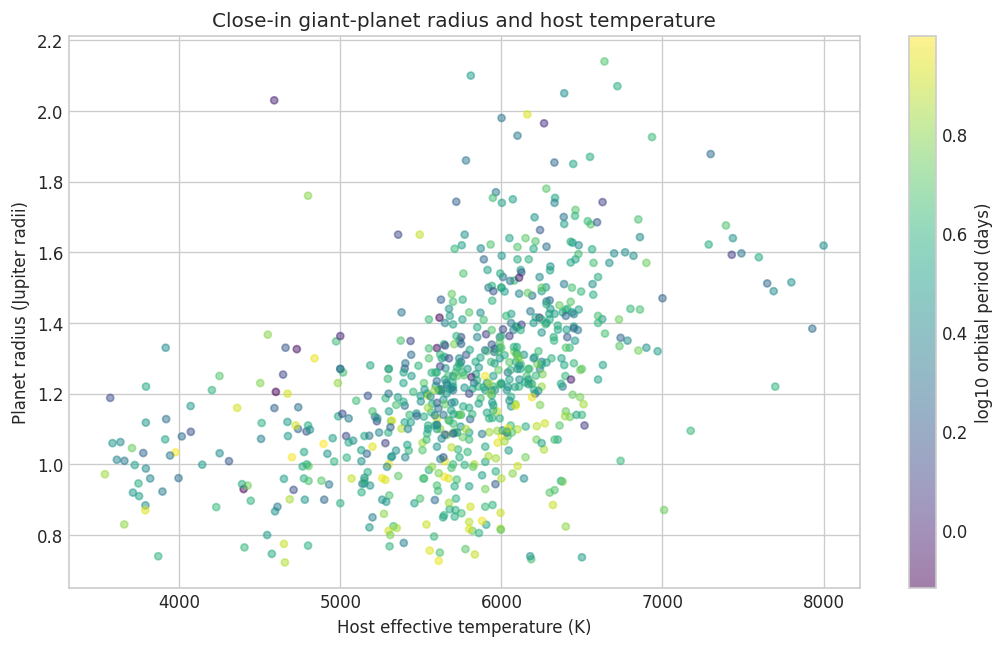

In [4]:
fig,ax=plt.subplots(figsize=(9,5.5)); sc=ax.scatter(sample.st_teff,sample.pl_radj,c=np.log10(sample.pl_orbper),s=18,alpha=.5,cmap="viridis")
ax.set(xlabel="Host effective temperature (K)",ylabel="Planet radius (Jupiter radii)",title="Close-in giant-planet radius and host temperature")
plt.colorbar(sc,ax=ax,label="log10 orbital period (days)"); fig.tight_layout(); fig.savefig("hot_jupiter_inflation.png",dpi=180); plt.show()

In [5]:
restricted=sample.dropna(subset=["pl_bmassj"]); restricted=restricted[restricted.pl_bmassj.between(.3,3)]
rho_mass=stats.spearmanr(restricted.st_teff,restricted.pl_radj).statistic
print(f"Mass-restricted N={len(restricted)}; rho={rho_mass:.3f}")

Mass-restricted N=529; rho=0.617


In [6]:
result={"id":"2026-07-31-hot-jupiter-radius-inflation","title":"Hot-Jupiter radius inflation","archive":"NASA Exoplanet Archive","date":"2026-07-31","question":"Are close-in giants larger around hotter stars?","sample_size":int(len(sample)),"results":[f"Spearman ρ = {rho:.3f}",f"bootstrap 68% interval {lo:.3f}–{hi:.3f}",f"mass-restricted ρ = {rho_mass:.3f} (N={len(restricted)})"],"validation":"The correlation is repeated for 0.3–3 Jupiter-mass planets.","notebook":"exoplanet-archive/2026-07-31-hot-jupiter-radius-inflation/notebook.ipynb","hero":"exoplanet-archive/2026-07-31-hot-jupiter-radius-inflation/hot_jupiter_inflation.png","tags":["hot Jupiters","radius inflation","rank correlation"]}
Path("result.json").write_text(json.dumps(result,indent=2)); print(result["results"])

['Spearman ρ = 0.558', 'bootstrap 68% interval 0.528–0.584', 'mass-restricted ρ = 0.617 (N=529)']


## Reading the result responsibly

The primary number answers the stated question only for the documented sample
and method. The stress test asks whether a reasonable threshold change reverses
the conclusion. Agreement does not remove shared selection effects, calibration
limits, unresolved multiplicity, or missing catalogue fields. Disagreement is
reported rather than hidden. A publishable follow-up would repeat the query
against a pinned archive release, model the survey selection function, and use
the original calibrated products where available.

The notebook deliberately separates observation, calculation, interpretation,
and limitation. That makes it useful as a learning record and makes each claim
easy for another reader to audit.

Numerical precision in the printed summary follows the scale supported by this
exercise; extra decimal places would not create extra physical accuracy. The
saved figure exposes the distribution behind the headline value, while the
machine-readable result file lets the dashboard report the finding without
scraping prose. Readers should inspect the executed cells before reusing any
number in a wider scientific argument.

## Sources and comparison literature

- NASA Exoplanet Archive, TAP guide: https://exoplanetarchive.ipac.caltech.edu/docs/TAP/usingTAP.html
- Planetary Systems table definitions: https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html
- Winn & Fabrycky (2015), *The Occurrence and Architecture of Exoplanetary Systems*: https://arxiv.org/abs/1410.4199
- Fulton et al. (2017), *A Gap in the Radius Distribution of Small Planets*: https://arxiv.org/abs/1703.10375

The literature provides physical context and expected population structure. It
does not make this heterogeneous archive selection complete or unbiased.